In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

import pandas as pd

import src.load_data as ld
import src.visualization as vsl

/home/tbm-demi/miniconda3/envs/finance_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = ld.load_parquet(file= "UCI_Credit_Card_cleaned")

df.info()

2026-04-03 11:01:57 - INFO - Execution time: 0.0312


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          30000 non-null  int64  
 1   LIMIT_BAL   30000 non-null  float64
 2   SEX         30000 non-null  object 
 3   EDUCATION   29986 non-null  object 
 4   MARRIAGE    30000 non-null  object 
 5   AGE         30000 non-null  int64  
 6   PAY_1       30000 non-null  int64  
 7   PAY_2       30000 non-null  int64  
 8   PAY_3       30000 non-null  int64  
 9   PAY_4       30000 non-null  int64  
 10  PAY_5       30000 non-null  int64  
 11  PAY_6       30000 non-null  int64  
 12  BILL_AMT1   30000 non-null  float64
 13  BILL_AMT2   30000 non-null  float64
 14  BILL_AMT3   30000 non-null  float64
 15  BILL_AMT4   30000 non-null  float64
 16  BILL_AMT5   30000 non-null  float64
 17  BILL_AMT6   30000 non-null  float64
 18  PAY_AMT1    30000 non-null  float64
 19  PAY_AMT2    30000 non-nul

2026-04-03 11:01:57 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/home/tbm-demi/Documents/Code/Finance/src/visualization.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data= df, x= column, palette= 'viridis', ax= ax,
2026-04-03 11:01:57 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/home/tbm-demi/Documents/Code/Finance/src/visualization.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation= 45)


<Axes: title={'center': 'Distribution by IS_DEFAULT'}, xlabel='IS_DEFAULT', ylabel='count'>

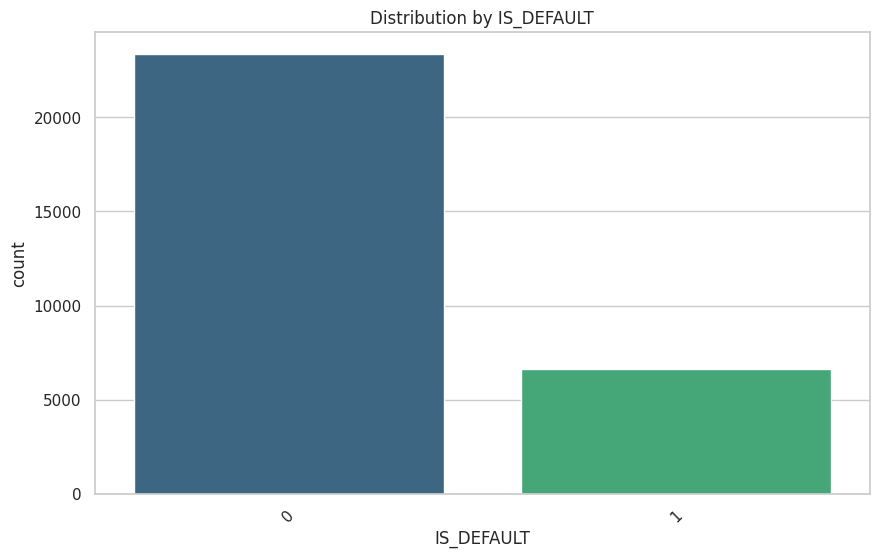

In [3]:
vsl.plot_catergorical(df= df, column= 'IS_DEFAULT')

/home/tbm-demi/Documents/Code/Finance/src/visualization.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation= 45)
2026-04-03 11:01:57 - INFO - Generated Distribution plot for: LIMIT_BAL


<Axes: title={'center': 'Distribution of LIMIT_BAL'}, xlabel='Limit Bal', ylabel='Frequency'>

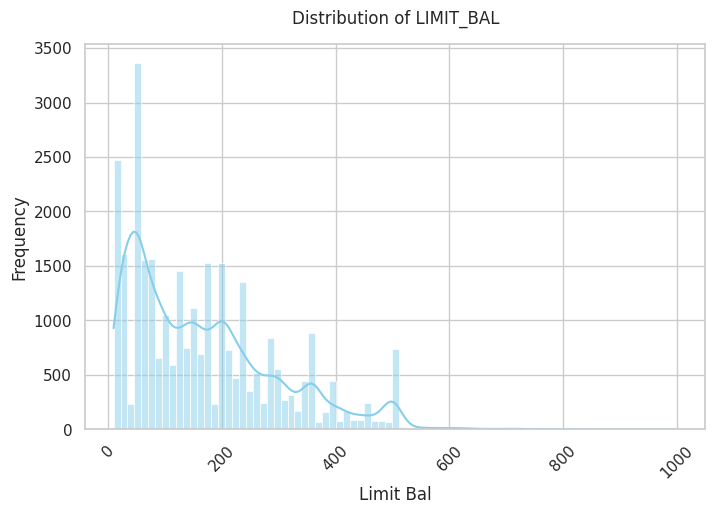

In [4]:
df['LIMIT_BAL'] = df['LIMIT_BAL'] / 1000

# Biều đồ tỷ lệ nợ xấu dựa trên hạn mức tín
vsl.plot_distribution(df= df, column= 'LIMIT_BAL')

/home/tbm-demi/Documents/Code/Finance/src/visualization.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation= 45)


<Axes: title={'center': 'Distribution by SEX'}, xlabel='SEX', ylabel='count'>

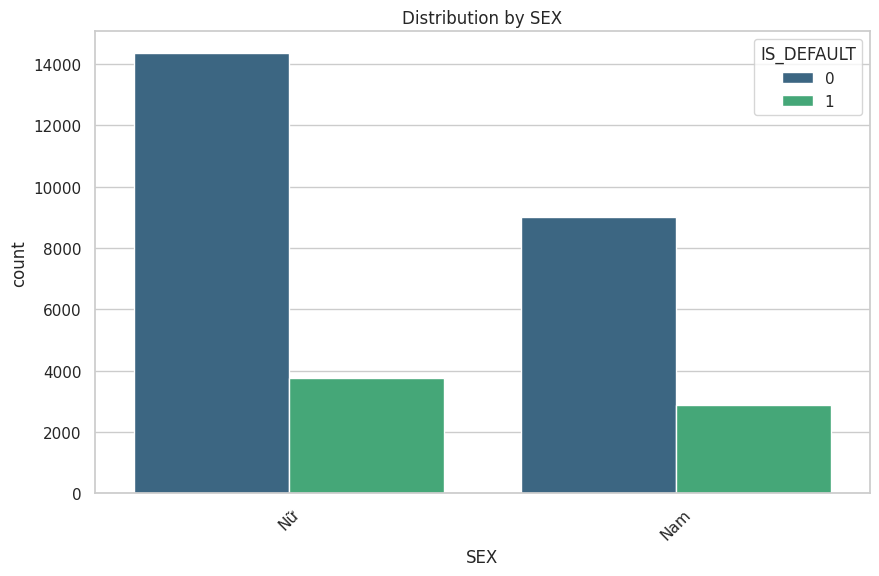

In [5]:
# Biểu đồ tỷ lệ nợ xấu dựa trên giới tính
vsl.plot_catergorical(df= df, column= 'SEX', hue= 'IS_DEFAULT')

/home/tbm-demi/Documents/Code/Finance/src/visualization.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation= 45)


<Axes: title={'center': 'Distribution by EDUCATION'}, xlabel='EDUCATION', ylabel='count'>

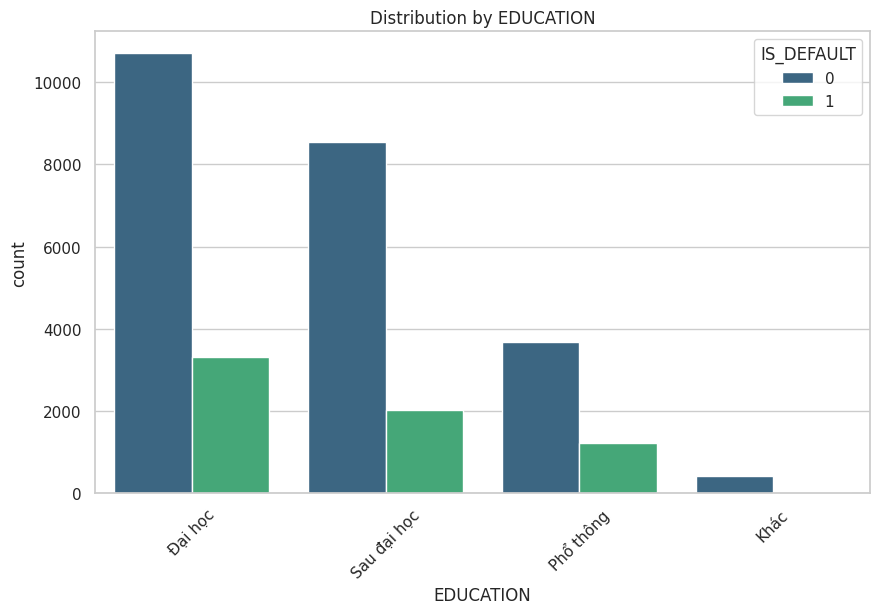

In [6]:
# Biểu đồ tỷ lệ nợ xấu dựa trên trình độ học vấn
vsl.plot_catergorical(df= df, column= 'EDUCATION', hue= 'IS_DEFAULT')

/home/tbm-demi/Documents/Code/Finance/src/visualization.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation= 45)


<Axes: title={'center': 'Distribution by MARRIAGE'}, xlabel='MARRIAGE', ylabel='count'>

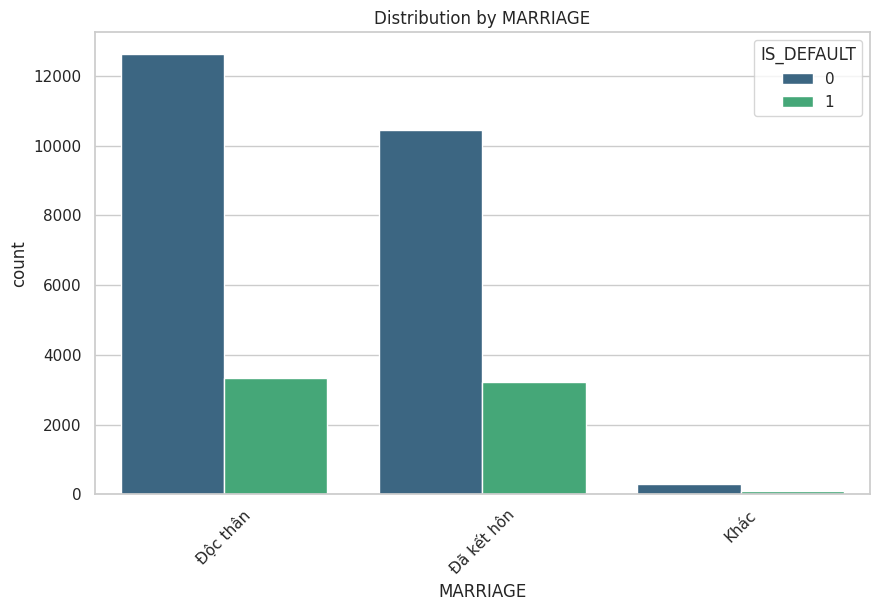

In [7]:
# Ty le no xau dua tren tinh trang hon nhan
vsl.plot_catergorical(df= df, column= 'MARRIAGE', hue= 'IS_DEFAULT')

/home/tbm-demi/Documents/Code/Finance/src/visualization.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation= 45)
2026-04-03 11:01:58 - INFO - Generated Distribution plot for: AGE_GROUP


<Axes: title={'center': 'Distribution of AGE_GROUP'}, xlabel='Age Group', ylabel='Frequency'>

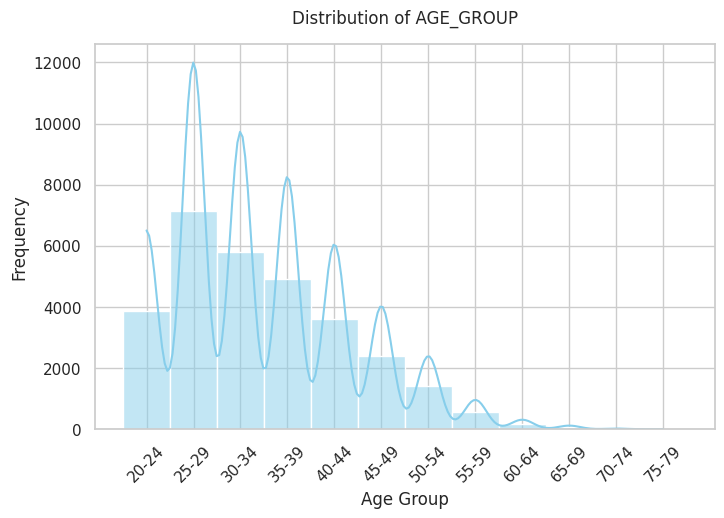

In [8]:
# Tỷ lệ nợ xáu dựa trên số tuổi
# Chia theo nhóm tuổi
bins = list(range(20, 81, 5))  #20, 25, ..., 80
labels = [f"{i}-{i + 4}" for i in bins[:-1]]
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=bins, labels=labels, right=True)

vsl.plot_distribution(df= df, column= 'AGE_GROUP')